In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Without markers nuclei: 43
With markers nuclei: 24


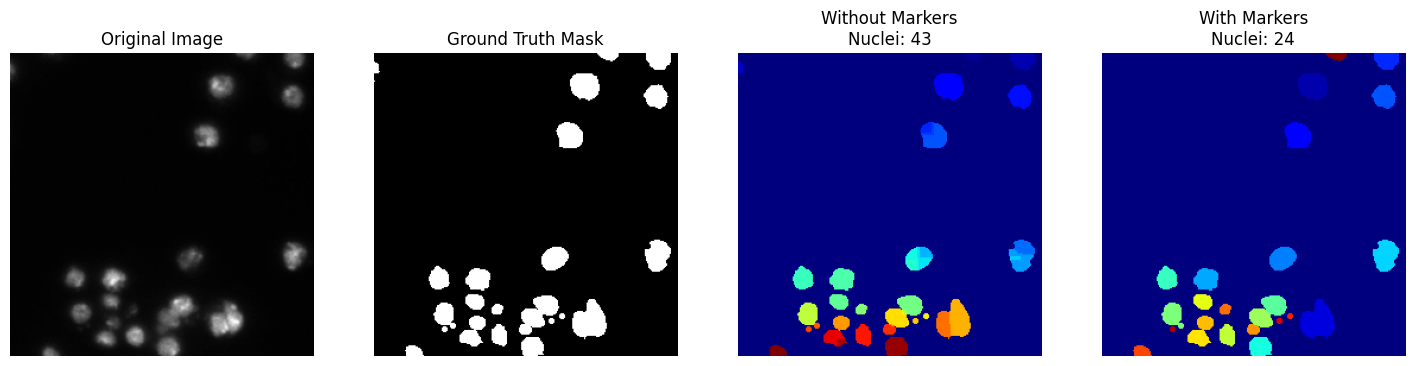

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

image_path = "/kaggle/input/data-science-bowl-2018-competition-merged-mask/data science bowl 2018/stage1_train 2/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/images/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552.png"
mask_path = "/kaggle/input/data-science-bowl-2018-competition-merged-mask/data science bowl 2018/stage1_train 2/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552/masks/00071198d059ba7f5914a526d124d28e6d010c92466da21d4a04cd5413362552_mask.png"

image = cv2.imread(image_path)
image_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
gt_mask = (gt_mask > 0).astype(np.uint8)

distance = cv2.distanceTransform(gt_mask, cv2.DIST_L2, 5)

labels_no_marker = watershed(-distance, mask=gt_mask)

coords = peak_local_max(distance, min_distance=5, labels=gt_mask)
markers = np.zeros(distance.shape, dtype=int)
for i, (r, c) in enumerate(coords):
    markers[r, c] = i + 1

labels_marker = watershed(-distance, markers, mask=gt_mask)

nuclei_no_marker = len(np.unique(labels_no_marker)) - 1
nuclei_marker = len(np.unique(labels_marker)) - 1

print("Without markers nuclei:", nuclei_no_marker)
print("With markers nuclei:", nuclei_marker)

plt.figure(figsize=(18,5))
plt.subplot(1,4,1)
plt.imshow(image_gray, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt_mask, cmap='gray')
plt.title("Ground Truth Mask")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(labels_no_marker, cmap='jet')
plt.title(f"Without Markers\nNuclei: {nuclei_no_marker}")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(labels_marker, cmap='jet')
plt.title(f"With Markers\nNuclei: {nuclei_marker}")
plt.axis("off")

plt.show()
